<a href="https://colab.research.google.com/github/rickyajs/Data-Science-2026/blob/main/Pertemuan_7_RickyArmandaJayaSirait_240401020219.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nama  : Ricky Armanda Jaya Sirait
# Nim   : 240401020219
#Kelas  : IF401
#Prodi  : PJJ S1 Informatika

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

=== Eksplorasi Data Awal ===
Shape dataset: (300, 4)

Statistik Deskriptif:
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


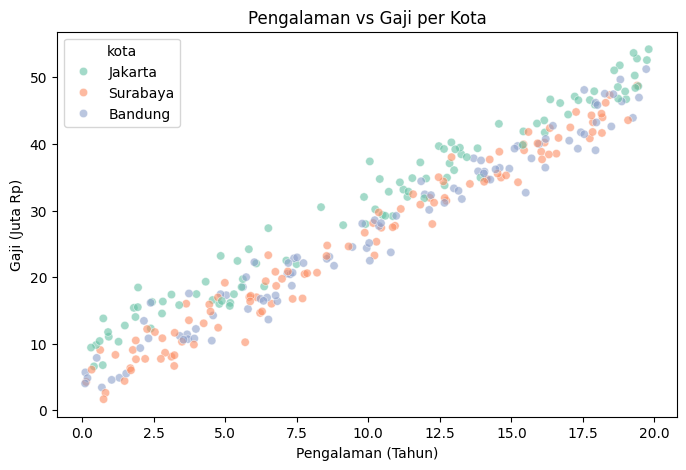

In [17]:
# Generate dataset sintetis
np.random.seed(42)
n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n) # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

# Rumus kalkulasi target gaji (juta rupiah)
gaji = (3.0 + 2.2 * pengalaman + 1.5 * edu
        + np.where(kota == 'Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))

# Membuat DataFrame
df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

# EDA singkat
print('=== Eksplorasi Data Awal ===')
print('Shape dataset:', df.shape)
print("\nStatistik Deskriptif:")
print(df.describe().round(2))

# Scatter Plot: Pengalaman vs Gaji per Kota
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.xlabel('Pengalaman (Tahun)')
plt.ylabel('Gaji (Juta Rp)')
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print('\n=== Proses Preprocessing ===')

# One-Hot Encoding pada kolom 'kota' (menghindari Dummy Variable Trap dengan drop_first=True)
# This line was commented out to prevent re-encoding an already transformed column.
# If you need to re-run from scratch, restart the runtime or re-create the 'df' DataFrame.
df = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int) # Uncommented this line
print('Kolom setelah encoding:', df.columns.tolist())

# Pisahkan fitur (X) dan target (y)
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train set: {X_train.shape[0]} baris')
print(f'Test set: {X_test.shape[0]} baris')

# Feature Scaling menggunakan StandardScaler (fit hanya pada training set)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


=== Proses Preprocessing ===
Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train set: 240 baris
Test set: 60 baris


In [ ]:
from sklearn.linear_model import LinearRegression

print('\n=== Regresi Linear ===')
model = LinearRegression()
model.fit(X_train_s, y_train)

# Tampilkan nilai Intercept dan Koefisien fitur
print(f'β₀ (intercept): {model.intercept_:.3f}')
print("\nKoefisien tiap fitur (diurutkan dari yang tertinggi):")
coef_df = pd.DataFrame({
    'Fitur' : X.columns,
    'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))


=== Regresi Linear ===
β₀ (intercept): 27.514

Koefisien tiap fitur (diurutkan dari yang tertinggi):
        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Melakukan prediksi pada data test
y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
# Perbaikan sintaks: parameter 'squared=False' sudah deprecated di versi scikit-learn terbaru.
# Cara mencari RMSE adalah dengan mengakar kuadratkan nilai MSE menggunakan np.sqrt().
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('\n=== Metrik Evaluasi ===')
print(f'MAE              = {mae:.3f} juta rupiah')
print(f'RMSE             = {rmse:.3f} juta rupiah')
print(f'R²               = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan oleh model)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')


=== Metrik Evaluasi ===
MAE              = 1.649 juta rupiah
RMSE             = 2.123 juta rupiah
R²               = 0.9740 (97.4% variasi dijelaskan oleh model)
Selisih RMSE-MAE = 0.474


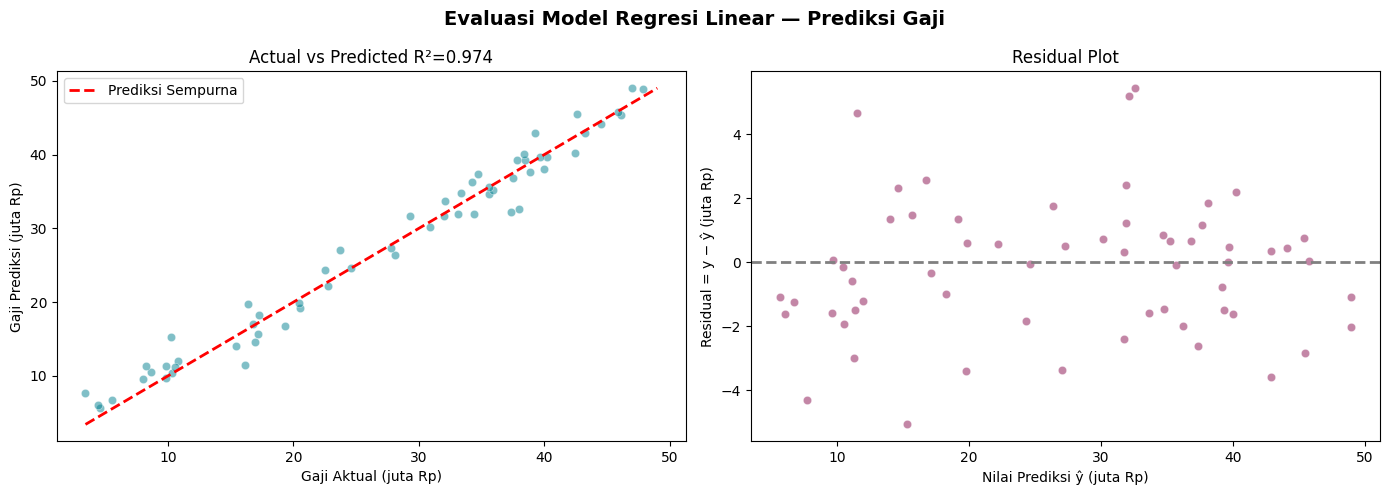

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted R²={r2:.3f}')
axes[0].legend()

# Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji', fontsize=14, fontweight='bold')
plt.tight_layout()

# Menyimpan hasil plot sebagai gambar
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()